<a href="https://colab.research.google.com/github/AiruxPH/model-rescue/blob/main/EFFDET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install effdet timm pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 5.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json, os

DATASET_DIR = "/content/drive/MyDrive/Itel03/Hand_Project_v2"
TRAIN_IMG   = f"{DATASET_DIR}/train"
VALID_IMG   = f"{DATASET_DIR}/valid"
TRAIN_ANN   = f"{DATASET_DIR}/train/_annotations.coco.json"
VALID_ANN   = f"{DATASET_DIR}/valid/_annotations.coco.json"

# Verify
for path in [TRAIN_ANN, VALID_ANN]:
    print(path, "→", os.path.exists(path))

with open(TRAIN_ANN) as f:
    ann = json.load(f)
print("Categories:", [(c['id'], c['name']) for c in ann['categories']])

Mounted at /content/drive
/content/drive/MyDrive/Itel03/Hand_Project_v2/train/_annotations.coco.json → True
/content/drive/MyDrive/Itel03/Hand_Project_v2/valid/_annotations.coco.json → True
Categories: [(0, 'hand-or-palm'), (1, 'hand'), (2, 'palm')]


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T
import json, os

class CocoHandDataset(Dataset):
    def __init__(self, img_dir, ann_file, img_size=256):
        with open(ann_file) as f:
            self.coco = json.load(f)

        self.img_dir  = img_dir
        self.img_size = img_size
        self.images   = self.coco['images']

        # Remap only categories that have annotations
        used_ids = sorted(set(
            a['category_id'] for a in self.coco['annotations']
        ))
        # effdet expects 1-indexed classes
        self.cat_remap = {old: new for new, old in enumerate(used_ids, start=1)}
        print("Class remap:", self.cat_remap)

        self.img_id_to_anns = {}
        for a in self.coco['annotations']:
            self.img_id_to_anns.setdefault(a['image_id'], []).append(a)

        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        info    = self.images[idx]
        img     = Image.open(os.path.join(self.img_dir, info['file_name'])).convert('RGB')

        anns    = self.img_id_to_anns.get(info['id'], [])

        boxes, labels = [], []
        for a in anns:
            x, y, bw, bh = a['bbox']

            # ✅ effdet expects [y1, x1, y2, x2] but in ABSOLUTE pixels!
            # We removed the division so the boxes stay full size.
            boxes.append([
                float(y),
                float(x),
                float(y + bh),
                float(x + bw)
            ])
            labels.append(self.cat_remap[a['category_id']])

        img_t  = self.transform(img)
        boxes  = torch.tensor(boxes,  dtype=torch.float32) if boxes  else torch.zeros((0, 4))
        labels = torch.tensor(labels, dtype=torch.float32) if labels else torch.zeros((0,))

        return img_t, {'bbox': boxes, 'cls': labels}

In [ ]:
def collate_fn(batch):
    imgs, targets = zip(*batch)
    imgs = torch.stack(imgs)
    return imgs, list(targets)

In [ ]:
from effdet import create_model
from effdet.anchors import Anchors, AnchorLabeler
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)

NUM_CLASSES = 2

train_ds = CocoHandDataset(TRAIN_IMG, TRAIN_ANN)
valid_ds = CocoHandDataset(VALID_IMG, VALID_ANN)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  collate_fn=collate_fn)
valid_loader = DataLoader(valid_ds, batch_size=8, shuffle=False, collate_fn=collate_fn)

# Create model in eval/predict mode (we handle loss manually)
model = create_model(
    'tf_efficientdet_d0',
    pretrained=True,
    num_classes=NUM_CLASSES,
    image_size=(256, 256),
    bench_task='train'
)
model = model.to(device)

# ✅ Create anchor labeler to pre-compute targets
anchors = Anchors.from_config(model.config)
anchor_labeler = AnchorLabeler(anchors, NUM_CLASSES, match_threshold=0.5)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

best_loss = float('inf')

for epoch in range(50):
    model.train()
    total_loss = 0

    for imgs, targets in train_loader:
        imgs = imgs.to(device)

        # ✅ Pre-compute anchor labels for each image in batch
        batch_targets = []
        for t in targets:
            cls_targets, box_targets, num_positives = anchor_labeler.batch_label_anchors(
                t['bbox'].unsqueeze(0),   # [1, N, 4]
                t['cls'].unsqueeze(0)     # [1, N]
            )
            batch_targets.append({
                'cls_targets':        [c.to(device) for c in cls_targets],
                'box_targets':        [b.to(device) for b in box_targets],
                'num_positives':      num_positives.to(device)
            })

        # Stack into batch format effdet expects
        tgts = {
            'label_num_positives': torch.stack([t['num_positives'] for t in batch_targets]),
        }
        for l in range(len(batch_targets[0]['cls_targets'])):
            tgts[f'label_cls_{l}']  = torch.stack([t['cls_targets'][l]  for t in batch_targets]).to(device)

Using: cuda
Class remap: {1: 1, 2: 2}
Class remap: {1: 1, 2: 2}


In [ ]:
# Run this in a new cell to check if weights are cached
import os
cache = '/root/.cache/torch/hub/checkpoints/'
files = os.listdir(cache) if os.path.exists(cache) else []
print(files)

['tf_efficientdet_d0_34-f153e0cf.pth']


In [ ]:
# Debug cell — run this instead of the full training loop
model.train()

# Grab just one batch
imgs, targets = next(iter(train_loader))
imgs = imgs.to(device)
print("Images shape:", imgs.shape)
print("Sample target:", targets[0])
print("Bbox shape:", targets[0]['bbox'].shape)
print("Cls shape:", targets[0]['cls'].shape)

# Try the anchor labeling step
try:
    cls_targets, box_targets, num_positives = anchor_labeler.batch_label_anchors(
        targets[0]['bbox'].unsqueeze(0),
        targets[0]['cls'].unsqueeze(0)
    )
    print("Anchor labeling OK")
    print("num_positives:", num_positives)
except Exception as e:
    print("Anchor labeling FAILED:", e)

# Try full forward pass
try:
    tgts = {
        'label_num_positives': num_positives.unsqueeze(0).to(device),
    }
    for l in range(len(cls_targets)):
        tgts[f'label_cls_{l}']  = cls_targets[l].unsqueeze(0).to(device)
        tgts[f'label_bbox_{l}'] = box_targets[l].unsqueeze(0).to(device)

    output = model(imgs[:1], tgts)
    print("Forward pass OK — Loss:", output['loss'].item())
except Exception as e:
    print("Forward pass FAILED:", e)

Images shape: torch.Size([8, 3, 256, 256])
Sample target: {'bbox': tensor([[0.2891, 0.2773, 0.4805, 0.4258],
        [0.3672, 0.2852, 0.4688, 0.3711]]), 'cls': tensor([1., 2.])}
Bbox shape: torch.Size([2, 4])
Cls shape: torch.Size([2])
Anchor labeling OK
num_positives: tensor([1.])
Forward pass FAILED: too many values to unpack (expected 5)


In [ ]:
from effdet import create_model
from effdet.anchors import Anchors, AnchorLabeler
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)

NUM_CLASSES = 2

train_ds = CocoHandDataset(TRAIN_IMG, TRAIN_ANN)
valid_ds = CocoHandDataset(VALID_IMG, VALID_ANN)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  collate_fn=collate_fn)
valid_loader = DataLoader(valid_ds, batch_size=8, shuffle=False, collate_fn=collate_fn)

model = create_model(
    'tf_efficientdet_d0',
    pretrained=True,
    num_classes=NUM_CLASSES,
    image_size=(256, 256),
    bench_task='train'
)
model = model.to(device)

anchors = Anchors.from_config(model.config)
anchor_labeler = AnchorLabeler(anchors, NUM_CLASSES, match_threshold=0.5)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# Early stopping config
PATIENCE    = 10   # stop if no improvement for 10 epochs
best_loss   = float('inf')
no_improve  = 0

def prepare_batch_targets(targets, anchor_labeler, device):
    all_cls, all_box, all_pos = [], [], []
    for t in targets:
        cls_t, box_t, num_pos = anchor_labeler.batch_label_anchors(
            t['bbox'].unsqueeze(0),
            t['cls'].unsqueeze(0)
        )
        all_cls.append(cls_t)
        all_box.append(box_t)
        all_pos.append(num_pos)

    num_levels = len(all_cls[0])
    tgts = {'label_num_positives': torch.cat(all_pos).to(device)}
    for l in range(num_levels):
        tgts[f'label_cls_{l}']  = torch.cat([c[l] for c in all_cls]).to(device)
        tgts[f'label_bbox_{l}'] = torch.cat([b[l] for b in all_box]).to(device)
    return tgts

for epoch in range(50):
    model.train()
    total_loss = 0

    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        try:
            tgts   = prepare_batch_targets(targets, anchor_labeler, device)
            optimizer.zero_grad()
            output = model(imgs, tgts)
            loss   = output['loss']

            if torch.isnan(loss):
                print(f"NaN at epoch {epoch+1}, skipping batch")
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        except Exception as e:
            print(f"Batch error: {e}")
            continue

    scheduler.step()
    avg_loss = total_loss / len(train_loader)

    # Early stopping check
    if avg_loss < best_loss:
        best_loss  = avg_loss
        no_improve = 0
        torch.save(model.state_dict(), '/content/efficientdet_best.pth')
        print(f"Epoch {epoch+1}/50 — Loss: {avg_loss:.4f} ✓ saved best model")
    else:
        no_improve += 1
        print(f"Epoch {epoch+1}/50 — Loss: {avg_loss:.4f} | No improve: {no_improve}/{PATIENCE}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} — no improvement for {PATIENCE} epochs")
        break

print(f"Training done! Best loss: {best_loss:.4f}")

Using: cuda
Class remap: {1: 1, 2: 2}
Class remap: {1: 1, 2: 2}
Epoch 1/50 — Loss: 1.1182 ✓ saved best model
Epoch 2/50 — Loss: 0.6289 ✓ saved best model
Epoch 3/50 — Loss: 0.4415 ✓ saved best model
Epoch 4/50 — Loss: 0.3530 ✓ saved best model
Epoch 5/50 — Loss: 0.3109 ✓ saved best model
Epoch 6/50 — Loss: 0.2736 ✓ saved best model
Epoch 7/50 — Loss: 0.2563 ✓ saved best model
Epoch 8/50 — Loss: 0.2365 ✓ saved best model
Epoch 9/50 — Loss: 0.2187 ✓ saved best model
Epoch 10/50 — Loss: 0.2041 ✓ saved best model
Epoch 11/50 — Loss: 0.1969 ✓ saved best model
Epoch 12/50 — Loss: 0.1823 ✓ saved best model
Epoch 13/50 — Loss: 0.1753 ✓ saved best model
Epoch 14/50 — Loss: 0.1715 ✓ saved best model
Epoch 15/50 — Loss: 0.1597 ✓ saved best model
Epoch 16/50 — Loss: 0.1523 ✓ saved best model
Epoch 17/50 — Loss: 0.1450 ✓ saved best model
Epoch 18/50 — Loss: 0.1364 ✓ saved best model
Epoch 19/50 — Loss: 0.1310 ✓ saved best model
Epoch 20/50 — Loss: 0.1275 ✓ saved best model
Epoch 21/50 — Loss: 0.123

In [ ]:
import shutil, os

size = os.path.getsize('/content/efficientdet_best.pth') / 1e6
print(f"Model size: {size:.1f} MB")

shutil.copy(
    '/content/efficientdet_best.pth',
    '/content/drive/MyDrive/Itel03/Hand_Project_v2/efficientdet_best.pth'
)
print("Saved to Drive!")

Model size: 16.0 MB
Saved to Drive!


In [ ]:
import torch
import json
from PIL import Image
import torchvision.transforms as T
from effdet import create_model
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# 1. Point it to your Google Drive dataset
DATASET_DIR = "/content/drive/MyDrive/Itel03/Hand_Project_v2"
VALID_ANN   = f"{DATASET_DIR}/valid/_annotations.coco.json"
VALID_IMG   = f"{DATASET_DIR}/valid"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Prepping the COCO Grader...")

# Load the answer key
coco_gt = COCO(VALID_ANN)

# 2. Spin up the model in "Test Mode"
eval_model = create_model(
    'tf_efficientdet_d0',
    pretrained=False,
    num_classes=2,
    image_size=(256, 256),
    bench_task='predict' # Telling it we are testing, not training!
)

# Load your rescued weights!
eval_model.load_state_dict(torch.load('/content/efficientdet_best.pth'))
eval_model = eval_model.to(device)
eval_model.eval() # Lock the model so it doesn't learn anymore

# The exact same image resizing you used during training
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

results = []
print("Taking the final exam. This might take a minute...")

# 3. Test on every single image in the validation folder
with torch.no_grad():
    for img_id in coco_gt.getImgIds():
        img_info = coco_gt.loadImgs(img_id)[0]
        img_path = f"{VALID_IMG}/{img_info['file_name']}"

        img = Image.open(img_path).convert('RGB')
        orig_w, orig_h = img.size
        img_tensor = transform(img).unsqueeze(0).to(device)

        # Get the model's guesses
        preds = eval_model(img_tensor)[0].cpu().numpy()

        for box in preds:
            x_min, y_min, x_max, y_max, score, cls_id = box

            # The model predicts on a tiny 256x256 square.
            # We have to scale those coordinates back up to fit the real image size.
            x_min = (x_min / 256.0) * orig_w
            x_max = (x_max / 256.0) * orig_w
            y_min = (y_min / 256.0) * orig_h
            y_max = (y_max / 256.0) * orig_h

            width = x_max - x_min
            height = y_max - y_min

            # Only record guesses it is at least 5% confident about
            if score > 0.05:
                results.append({
                    "image_id": img_id,
                    "category_id": int(cls_id),
                    "bbox": [float(x_min), float(y_min), float(width), float(height)],
                    "score": float(score)
                })

# 4. Hand the test into the grader
if len(results) > 0:
    # Save guesses to a temp file
    with open('/content/temp_results.json', 'w') as f:
        json.dump(results, f)

    # Compare guesses (dt) to the answer key (gt)
    coco_dt = coco_gt.loadRes('/content/temp_results.json')
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    print("\n--- EFFICIENTDET REPORT CARD ---")
    coco_eval.summarize()
else:
    print("Uh oh, the model didn't make any confident predictions!")

Prepping the COCO Grader...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Taking the final exam. This might take a minute...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.04s).
Accumulating evaluation results...
DONE (t=0.02s).

--- EFFICIENTDET REPORT CARD ---
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.429
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.712
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.498
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.331
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.644
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.552
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.418
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.503
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDe

In [ ]:
import torch
from PIL import Image
import torchvision.transforms as T

# Grab the very first image from your validation set
img_id = coco_gt.getImgIds()[0]
img_info = coco_gt.loadImgs(img_id)[0]
img_path = f"{VALID_IMG}/{img_info['file_name']}"

img = Image.open(img_path).convert('RGB')
img_tensor = transform(img).unsqueeze(0).to(device)

print(f"Testing image: {img_info['file_name']}")

with torch.no_grad():
    # Get the raw predictions directly from the model
    preds = eval_model(img_tensor)[0].cpu().numpy()

    print(f"Model found {len(preds)} total raw boxes.")
    print("-" * 40)

    # Show the top 5 most confident guesses
    for i, box in enumerate(preds[:5]):
        x_min, y_min, x_max, y_max, score, cls_id = box
        print(f"Guess {i+1} | Class: {cls_id} | Score: {score:.4f} | Box: [{x_min:.2f}, {y_min:.2f}, {x_max:.2f}, {y_max:.2f}]")

Testing image: 0bccb353-1aab-433a-931d-41746dd7be49_jpg.rf.9c4cfe6f385d38042e0e542a3e3f2c97.jpg
Model found 100 total raw boxes.
----------------------------------------
Guess 1 | Class: 1.0 | Score: 0.9774 | Box: [0.26, 0.19, 0.47, 0.43]
Guess 2 | Class: 2.0 | Score: 0.0120 | Box: [0.26, 0.19, 0.47, 0.43]
Guess 3 | Class: 1.0 | Score: 0.0108 | Box: [-19.44, -2.29, 27.70, 20.13]
Guess 4 | Class: 2.0 | Score: 0.0095 | Box: [-7.35, -5.59, 59.59, 14.62]
Guess 5 | Class: 2.0 | Score: 0.0092 | Box: [-23.70, -9.06, 28.85, 11.67]


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import json, os
import torchvision.transforms as T

class CocoHandDataset(Dataset):
    def __init__(self, img_dir, ann_file, img_size=256):
        with open(ann_file) as f:
            self.coco = json.load(f)

        self.img_dir = img_dir
        self.img_size = img_size
        self.images = self.coco['images']

        # Remap: skip hand-or-palm (0), remap hand→1, palm→2
        used_ids = sorted(set(
            ann['category_id'] for ann in self.coco['annotations']
        ))
        self.cat_remap = {old_id: new_id for new_id, old_id in enumerate(used_ids, start=1)}

        self.img_id_to_anns = {}
        for ann in self.coco['annotations']:
            iid = ann['image_id']
            self.img_id_to_anns.setdefault(iid, []).append(ann)

        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        img = Image.open(img_path).convert('RGB')

        anns = self.img_id_to_anns.get(img_info['id'], [])
        boxes, labels = [], []
        for ann in anns:
            x, y, bw, bh = ann['bbox']
            # NO MORE DIVISION! Just absolute pixel coordinates
            boxes.append([
                float(x), float(y),
                float(x + bw), float(y + bh)
            ])
            labels.append(self.cat_remap[ann['category_id']])

        img_tensor = self.transform(img)
        boxes  = torch.tensor(boxes,  dtype=torch.float32) if boxes  else torch.zeros((0,4))
        labels = torch.tensor(labels, dtype=torch.int64)   if labels else torch.zeros((0,), dtype=torch.int64)

        return img_tensor, {'boxes': boxes, 'labels': labels}

cocograder but on test folder

In [1]:
import torch
import json
from PIL import Image
import torchvision.transforms as T
from effdet import create_model
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# 1. Point it to the TEST folder this time
DATASET_DIR = "/content/drive/MyDrive/Itel03/Hand_Project_v2"
TEST_ANN    = f"{DATASET_DIR}/test/_annotations.coco.json"
TEST_IMG    = f"{DATASET_DIR}/test"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Prepping the COCO Grader for the TRUE Final Exam...")

# Load the test answer key
coco_gt = COCO(TEST_ANN)

# 2. Spin up the model in "Test Mode"
eval_model = create_model(
    'tf_efficientdet_d0',
    pretrained=False,
    num_classes=2,
    image_size=(256, 256),
    bench_task='predict'
)

# Load your rescued weights!
eval_model.load_state_dict(torch.load('/content/drive/MyDrive/Itel03/Hand_Project_v2/efficientdet_best.pth'))
eval_model = eval_model.to(device)
eval_model.eval()

# The exact same image resizing
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

results = []
print("Taking the test exam. Please wait a minute...")

# 3. Test on every single image in the TEST folder
with torch.no_grad():
    for img_id in coco_gt.getImgIds():
        img_info = coco_gt.loadImgs(img_id)[0]
        img_path = f"{TEST_IMG}/{img_info['file_name']}"

        img = Image.open(img_path).convert('RGB')
        orig_w, orig_h = img.size
        img_tensor = transform(img).unsqueeze(0).to(device)

        # Get the model's guesses
        preds = eval_model(img_tensor)[0].cpu().numpy()

        for box in preds:
            x_min, y_min, x_max, y_max, score, cls_id = box

            # Scale coordinates back up
            x_min = (x_min / 256.0) * orig_w
            x_max = (x_max / 256.0) * orig_w
            y_min = (y_min / 256.0) * orig_h
            y_max = (y_max / 256.0) * orig_h

            width = x_max - x_min
            height = y_max - y_min

            if score > 0.05:
                results.append({
                    "image_id": img_id,
                    "category_id": int(cls_id),
                    "bbox": [float(x_min), float(y_min), float(width), float(height)],
                    "score": float(score)
                })

# 4. Hand the test into the grader
if len(results) > 0:
    with open('/content/temp_test_results.json', 'w') as f:
        json.dump(results, f)

    coco_dt = coco_gt.loadRes('/content/temp_test_results.json')
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    print("\n--- OFFICIAL TEST SET REPORT CARD ---")
    coco_eval.summarize()
else:
    print("Uh oh, the model didn't make any confident predictions!")

ModuleNotFoundError: No module named 'effdet'

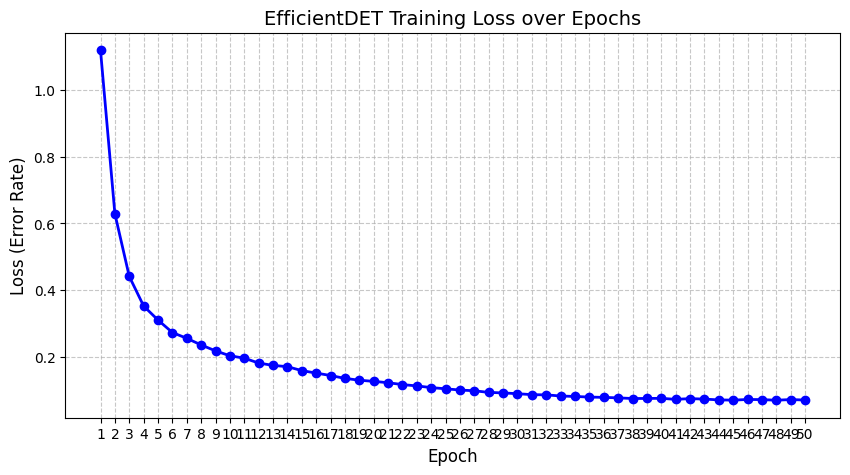

In [ ]:
import matplotlib.pyplot as plt

# 1. Just copy and paste the printed text from your training cell right here!
# It doesn't matter if it has the "saved best model" text, the code will clean it.
logs = """
Epoch 1/50 — Loss: 1.1182 ✓ saved best model
Epoch 2/50 — Loss: 0.6289 ✓ saved best model
Epoch 3/50 — Loss: 0.4415 ✓ saved best model
Epoch 4/50 — Loss: 0.3530 ✓ saved best model
Epoch 5/50 — Loss: 0.3109 ✓ saved best model
Epoch 6/50 — Loss: 0.2736 ✓ saved best model
Epoch 7/50 — Loss: 0.2563 ✓ saved best model
Epoch 8/50 — Loss: 0.2365 ✓ saved best model
Epoch 9/50 — Loss: 0.2187 ✓ saved best model
Epoch 10/50 — Loss: 0.2041 ✓ saved best model
Epoch 11/50 — Loss: 0.1969 ✓ saved best model
Epoch 12/50 — Loss: 0.1823 ✓ saved best model
Epoch 13/50 — Loss: 0.1753 ✓ saved best model
Epoch 14/50 — Loss: 0.1715 ✓ saved best model
Epoch 15/50 — Loss: 0.1597 ✓ saved best model
Epoch 16/50 — Loss: 0.1523 ✓ saved best model
Epoch 17/50 — Loss: 0.1450 ✓ saved best model
Epoch 18/50 — Loss: 0.1364 ✓ saved best model
Epoch 19/50 — Loss: 0.1310 ✓ saved best model
Epoch 20/50 — Loss: 0.1275 ✓ saved best model
Epoch 21/50 — Loss: 0.1235 ✓ saved best model
Epoch 22/50 — Loss: 0.1179 ✓ saved best model
Epoch 23/50 — Loss: 0.1139 ✓ saved best model
Epoch 24/50 — Loss: 0.1089 ✓ saved best model
Epoch 25/50 — Loss: 0.1053 ✓ saved best model
Epoch 26/50 — Loss: 0.1016 ✓ saved best model
Epoch 27/50 — Loss: 0.0994 ✓ saved best model
Epoch 28/50 — Loss: 0.0945 ✓ saved best model
Epoch 29/50 — Loss: 0.0930 ✓ saved best model
Epoch 30/50 — Loss: 0.0906 ✓ saved best model
Epoch 31/50 — Loss: 0.0878 ✓ saved best model
Epoch 32/50 — Loss: 0.0871 ✓ saved best model
Epoch 33/50 — Loss: 0.0838 ✓ saved best model
Epoch 34/50 — Loss: 0.0823 ✓ saved best model
Epoch 35/50 — Loss: 0.0806 ✓ saved best model
Epoch 36/50 — Loss: 0.0796 ✓ saved best model
Epoch 37/50 — Loss: 0.0782 ✓ saved best model
Epoch 38/50 — Loss: 0.0762 ✓ saved best model
Epoch 39/50 — Loss: 0.0764 | No improve: 1/10
Epoch 40/50 — Loss: 0.0768 | No improve: 2/10
Epoch 41/50 — Loss: 0.0737 ✓ saved best model
Epoch 42/50 — Loss: 0.0759 | No improve: 1/10
Epoch 43/50 — Loss: 0.0745 | No improve: 2/10
Epoch 44/50 — Loss: 0.0721 ✓ saved best model
Epoch 45/50 — Loss: 0.0714 ✓ saved best model
Epoch 46/50 — Loss: 0.0733 | No improve: 1/10
Epoch 47/50 — Loss: 0.0730 | No improve: 2/10
Epoch 48/50 — Loss: 0.0711 ✓ saved best model
Epoch 49/50 — Loss: 0.0731 | No improve: 1/10
Epoch 50/50 — Loss: 0.0717 | No improve: 2/10
"""

epochs = []
losses = []

# 2. A quick back-end parser to extract the numbers
for line in logs.strip().split('\n'):
    if "Epoch" in line and "Loss" in line:
        # Extract the epoch number
        epoch_str = line.split('/')[0].replace("Epoch", "").strip()
        # Extract the loss number
        loss_str = line.split('Loss:')[1].split()[0].strip()

        epochs.append(int(epoch_str))
        losses.append(float(loss_str))

# 3. Draw the graph!
plt.figure(figsize=(10, 5))
plt.plot(epochs, losses, marker='o', linestyle='-', color='b', linewidth=2)
plt.title('EfficientDET Training Loss over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Error Rate)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(epochs)

# Save it as an image for your documentation
plt.savefig('/content/training_loss_graph.png', bbox_inches='tight')
plt.show()

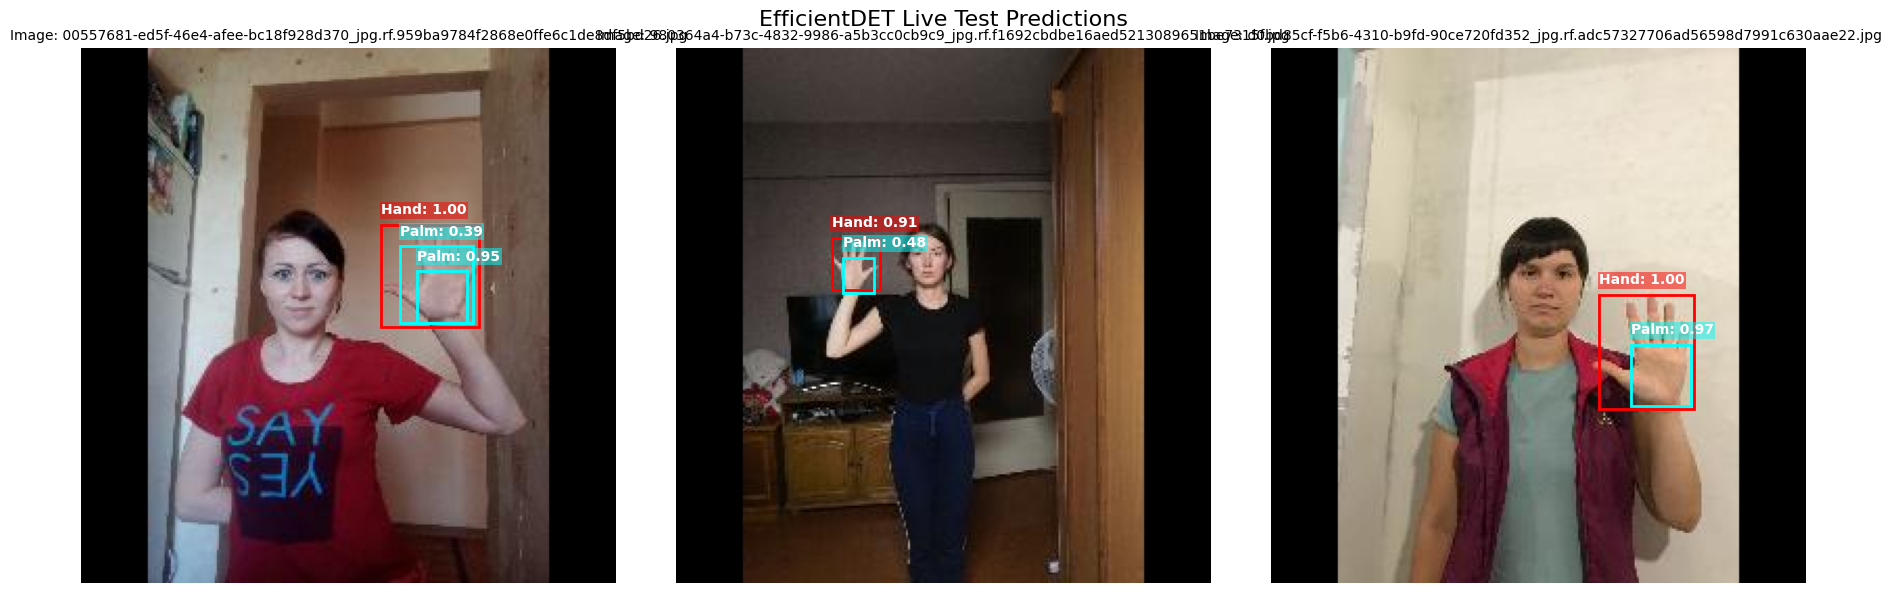

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

# Grab 3 random images from your test answer key
sample_ids = random.sample(coco_gt.getImgIds(), 3)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('EfficientDET Live Test Predictions', fontsize=16)

with torch.no_grad():
    for i, img_id in enumerate(sample_ids):
        # Load the image
        img_info = coco_gt.loadImgs(img_id)[0]
        img_path = f"{TEST_IMG}/{img_info['file_name']}"
        img = Image.open(img_path).convert('RGB')
        orig_w, orig_h = img.size

        # Prep the image for the model
        img_tensor = transform(img).unsqueeze(0).to(device)

        # Get predictions
        preds = eval_model(img_tensor)[0].cpu().numpy()

        # Draw the image
        ax = axes[i]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Image: {img_info['file_name']}", fontsize=10)

        # Draw the boxes!
        for box in preds:
            x_min, y_min, x_max, y_max, score, cls_id = box

            if score > 0.30: # Only draw if it's 30% confident or higher
                # Scale the box back to normal size
                x_min = (x_min / 256.0) * orig_w
                y_min = (y_min / 256.0) * orig_h
                width = ((x_max - x_min) / 256.0) * orig_w
                height = ((y_max - y_min) / 256.0) * orig_h

                # Pick a color (Red for hand, Blue for palm, etc)
                color = 'red' if int(cls_id) == 1 else 'cyan'
                label = 'Hand' if int(cls_id) == 1 else 'Palm'

                # Draw the rectangle
                rect = patches.Rectangle((x_min, y_min), width, height,
                                         linewidth=2, edgecolor=color, facecolor='none')
                ax.add_patch(rect)

                # Add the label and score
                ax.text(x_min, y_min - 5, f'{label}: {score:.2f}',
                        color='white', fontsize=10, weight='bold',
                        bbox=dict(facecolor=color, alpha=0.5, pad=1, edgecolor='none'))

plt.tight_layout()
plt.savefig('/content/visual_predictions.png', bbox_inches='tight')
plt.show()

In [ ]:
import csv

# We are pulling the exact grades out of the hidden 'stats' list inside the grader
# stats[1] is your mAP50 score
# stats[0] is your strict mAP50-95 score
# stats[8] is your overall Recall score
metrics = {
    "Model": "EfficientDET-d0",
    "mAP50": round(coco_eval.stats[1], 4),
    "mAP50-95": round(coco_eval.stats[0], 4),
    "Recall": round(coco_eval.stats[8], 4)
}

# Dump these numbers into a CSV file so you can open it in Excel or Google Sheets
csv_file = '/content/efficientdet_test_data.csv'
with open(csv_file, mode='w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=metrics.keys())
    writer.writeheader()
    writer.writerow(metrics)

print(f"Boom! Data saved to {csv_file}")
print("-" * 40)
print("Here are your exact comparison numbers to put next to YOLO:")
for key, value in metrics.items():
    print(f"{key}: {value}")

Boom! Data saved to /content/efficientdet_test_data.csv
----------------------------------------
Here are your exact comparison numbers to put next to YOLO:
Model: EfficientDET-d0
mAP50: 0.7033
mAP50-95: 0.4313
Recall: 0.4938


In [ ]:
import shutil, os

size = os.path.getsize('/content/efficientdet_test_data.csv') / 1e6
print(f"Model size: {size:.1f} MB")

shutil.copy(
    '/content/efficientdet_test_data.csv',
    '/content/drive/MyDrive/Itel03/Hand_Project_v2/efficientdet_test_data.csv'
)
print("Saved to Drive!")

Model size: 0.0 MB
Saved to Drive!


**SSD and FASTER CNN**

In [ ]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.ssd import SSDHead
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import json, os

DATASET_DIR = "/content/drive/MyDrive/Itel03/Hand_Project_v2"

class TorchvisionHandDataset(Dataset):
    def __init__(self, img_dir, ann_file, img_size=256):
        with open(ann_file) as f:
            self.coco = json.load(f)

        self.img_dir  = img_dir
        self.images   = self.coco['images']

        # PyTorch REQUIRES Class 0 to be "Background". Hand=1, Palm=2.
        used_ids = sorted(set(a['category_id'] for a in self.coco['annotations']))
        self.cat_remap = {old: new for new, old in enumerate(used_ids, start=1)}

        self.img_id_to_anns = {}
        for a in self.coco['annotations']:
            self.img_id_to_anns.setdefault(a['image_id'], []).append(a)

        # Removed the manual Normalization! PyTorch does it automatically.
        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        info = self.images[idx]
        img = Image.open(os.path.join(self.img_dir, info['file_name'])).convert('RGB')

        anns = self.img_id_to_anns.get(info['id'], [])
        boxes, labels = [], []

        for a in anns:
            x, y, bw, bh = a['bbox']
            # ✅ Standard [x_min, y_min, x_max, y_max] format for Native PyTorch!
            boxes.append([float(x), float(y), float(x + bw), float(y + bh)])
            labels.append(self.cat_remap[a['category_id']])

        img_t = self.transform(img)
        boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4))
        labels = torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)

        return img_t, {'boxes': boxes, 'labels': labels}

def collate_fn(batch):
    return tuple(zip(*batch))

In [ ]:
# --- CHOOSE YOUR FIGHTER ---
MODEL_CHOICE = "SSD"
# MODEL_CHOICE = "FASTER_RCNN"
# ---------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = 3 # 0: Background, 1: Hand, 2: Palm

print(f"Loading up {MODEL_CHOICE} on {device}...")

# 1. Build the selected model
if MODEL_CHOICE == "FASTER_RCNN":
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

elif MODEL_CHOICE == "SSD":
    model = torchvision.models.detection.ssd300_vgg16(weights="DEFAULT")
    in_channels = torchvision.models.detection._utils.retrieve_out_channels(model.backbone, (300, 300))
    num_anchors = model.anchor_generator.num_anchors_per_location()
    model.head = SSDHead(in_channels, num_anchors, num_classes)

model = model.to(device)

# 2. Load the data
train_ds = TorchvisionHandDataset(f"{DATASET_DIR}/train", f"{DATASET_DIR}/train/_annotations.coco.json")
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=collate_fn)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# 3. Train it!
print("Starting the engine...")
for epoch in range(15): # These models converge fast, so 15 epochs is a great start
    model.train()
    total_loss = 0

    for imgs, targets in train_loader:
        imgs = list(img.to(device) for img in imgs)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        # Native PyTorch models return a dictionary of losses automatically!
        loss_dict = model(imgs, targets)
        loss = sum(loss for loss in loss_dict.values())

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/15 — Loss: {avg_loss:.4f}")

# 4. Save to Google Drive
save_path = f'/content/drive/MyDrive/Itel03/Hand_Project_v2/{MODEL_CHOICE.lower()}_best.pth'
torch.save(model.state_dict(), save_path)
print(f"Training Done! Model saved securely to: {save_path}")

Loading up SSD on cuda...
Starting the engine...
Epoch 1/15 — Loss: 6.2827
Epoch 2/15 — Loss: 4.3448
Epoch 3/15 — Loss: 3.0968
